In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline

## 1. Load & Explore Data

In [2]:
df = pd.read_csv("Crop_recommendation.csv")
print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())
df.head()

Shape: (6596, 8)

Class Distribution:
label
potato          461
onion           383
sorghum         367
sunflower       362
rapeseed        361
ragi            293
horsegram       272
wheat           264
turmeric        259
sweet_potato    241
soybean         196
barley          192
coriander       190
garlic          180
banana          100
chickpea        100
apple           100
blackgram       100
coconut         100
kidneybeans     100
pomegranate     100
orange          100
pigeonpeas      100
mungbean        100
muskmelon       100
mothbeans       100
papaya          100
watermelon      100
cotton          100
coffee          100
jute            100
maize           100
lentil          100
mango           100
grapes          100
rice            100
blackpepper      71
tomato           43
brinjal          43
cardamom         41
okra             32
pineapple        24
cabbage          21
cauliflower      18
jackfruit        16
drumstick        14
cucumber         14
radish          

,N,P,K,temperature,humidity,ph,rainfall,label
0,24,128,196,22.750888,90.694892,5.521467,110.431786,apple
1,7,144,197,23.849401,94.348150,6.133221,114.051249,apple
2,14,128,205,22.608010,94.589006,6.226290,116.039659,apple
3,8,120,201,21.186674,91.134357,6.321152,122.233323,apple
4,20,129,201,23.410447,91.699133,5.587906,116.077793,apple


## 2. Preprocessing

In [3]:
X = df.drop('label', axis=1)
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Features:", list(X.columns))
print("Number of classes:", len(le.classes_))
print("Classes:", list(le.classes_))

Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Number of classes: 51
Classes: ['apple', 'banana', 'barley', 'bitter_gourd', 'blackgram', 'blackpepper', 'bottle_gourd', 'brinjal', 'cabbage', 'cardamom', 'cauliflower', 'chickpea', 'coconut', 'coffee', 'coriander', 'cotton', 'cucumber', 'drumstick', 'garlic', 'grapes', 'horsegram', 'jackfruit', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'okra', 'onion', 'orange', 'papaya', 'pigeonpeas', 'pineapple', 'pomegranate', 'potato', 'pumpkin', 'radish', 'ragi', 'rapeseed', 'rice', 'sorghum', 'soybean', 'sunflower', 'sweet_potato', 'tomato', 'turmeric', 'watermelon', 'wheat']


In [4]:
# ── Train/test split with stratification ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # ensures all classes are represented
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (5276, 7), Test: (1320, 7)


## 3. Baseline Random forest

In [5]:
# ── Baseline: plain RF without scaling (your original approach) ──
baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_rf.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline_rf.predict(X_test))

sample_raw = [[90, 40, 40, 25, 80, 6.5, 200]]
baseline_conf = max(baseline_rf.predict_proba(sample_raw)[0])
print(f"Baseline Accuracy : {baseline_acc:.4f}")
print(f"Baseline Confidence (raw list): {baseline_conf:.4f}")

Baseline Accuracy : 0.9970
Baseline Confidence (raw list): 0.5400


c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## 4. Enhanced Pipeline: Scaler + RF + Calibration

In [7]:
# ── Step 1: Tune Random Forest with GridSearchCV ──
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Scale features first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

grid_search.fit(X_train_scaled, y_train)
print("Best Params:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Score: 0.9988627387620278


In [9]:
# ── Step 2: Calibrate the best RF for better probabilities ──
best_rf = grid_search.best_estimator_

calibrated_rf = CalibratedClassifierCV(
    estimator=best_rf,
    method='isotonic',   # 'isotonic' works best for large datasets
    cv=5
)
calibrated_rf.fit(X_train_scaled, y_train)

tuned_acc = accuracy_score(y_test, calibrated_rf.predict(X_test_scaled))
print(f"Tuned + Calibrated Accuracy: {tuned_acc:.4f}")

c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python31

Tuned + Calibrated Accuracy: 0.9962


## 5. Build Final Pipeline (Scaler + Calibrated RF)

In [10]:
# ── Build a single Pipeline so prediction is a one-liner ──
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  CalibratedClassifierCV(
                   estimator=grid_search.best_estimator_,
                   method='isotonic',
                   cv=5
               ))
])

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)
print(f"Final Pipeline Accuracy: {final_acc:.4f}")

c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python31

Final Pipeline Accuracy: 0.9962


In [11]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
      barley       1.00      1.00      1.00        38
bitter_gourd       1.00      1.00      1.00         2
   blackgram       0.95      0.95      0.95        20
 blackpepper       1.00      1.00      1.00        14
bottle_gourd       1.00      1.00      1.00         2
     brinjal       1.00      1.00      1.00         9
     cabbage       1.00      1.00      1.00         4
    cardamom       1.00      1.00      1.00         8
 cauliflower       1.00      1.00      1.00         4
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
   coriander       1.00      1.00      1.00        38
      cotton       1.00      1.00      1.00        20
    cucumber       1.00      1.00      1.00         3
   

## 6. Feature Importance

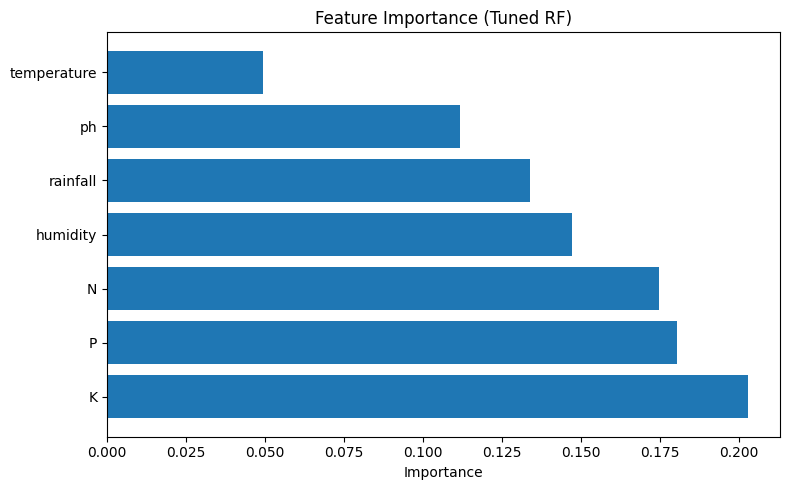

In [12]:
# Feature importance from the underlying RF
rf_model = grid_search.best_estimator_
importance = rf_model.feature_importances_
features   = X.columns

sorted_idx = np.argsort(importance)[::-1]

plt.figure(figsize=(8, 5))
plt.barh([features[i] for i in sorted_idx], [importance[i] for i in sorted_idx])
plt.xlabel("Importance")
plt.title("Feature Importance (Tuned RF)")
plt.tight_layout()
plt.show()

## 7. Save Model & Encoder

In [13]:
os.makedirs('../backend', exist_ok=True)
pickle.dump(final_pipeline, open('../backend/model.pkl', 'wb'))
pickle.dump(le,             open('../backend/encoder.pkl', 'wb'))
print(' Model and encoder saved to ../backend/')

 Model and encoder saved to ../backend/


## 8. Prediction with Confidence (≥ 80% target)

The helper function below:
- Returns **top-3** crops with confidence
- Applies a **confidence threshold** — if below 80%, warns the user

In [14]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall,
                 threshold=0.80, top_n=3):
    """
    Predict the best crop and return top-N crops with confidence scores.
    
    Parameters
    ----------
    N, P, K        : Soil nutrients
    temperature    : Temperature in °C
    humidity       : Relative humidity %
    ph             : Soil pH
    rainfall       : Rainfall in mm
    threshold      : Minimum confidence to accept prediction (default 0.80)
    top_n          : Number of top crops to return
    
    Returns
    -------
    dict with 'best_crop', 'confidence', 'top_crops', 'reliable'
    """
    # Pass as DataFrame to avoid UserWarning about feature names
    sample = pd.DataFrame(
        [[N, P, K, temperature, humidity, ph, rainfall]],
        columns=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
    )

    probs      = final_pipeline.predict_proba(sample)[0]
    top_idx    = np.argsort(probs)[::-1][:top_n]
    top_crops  = [(le.inverse_transform([i])[0], probs[i]) for i in top_idx]

    best_crop  = top_crops[0][0]
    confidence = top_crops[0][1]
    reliable   = confidence >= threshold

    return {
        'best_crop' : best_crop,
        'confidence': confidence,
        'top_crops' : top_crops,
        'reliable'  : reliable
    }


# ── Test prediction ──
result = predict_crop(N=90, P=40, K=40, temperature=25,
                      humidity=80, ph=6.5, rainfall=200)

print(f"\n🌾 Best Crop   : {result['best_crop']}")
print(f"📊 Confidence  : {result['confidence']*100:.2f}%")
print(f"✅ Reliable?   : {'Yes' if result['reliable'] else 'No — below 80% threshold'}")
print(f"\n🏆 Top-{len(result['top_crops'])} Predictions:")
for rank, (crop, prob) in enumerate(result['top_crops'], 1):
    bar = '█' * int(prob * 30)
    print(f"  {rank}. {crop:<20} {prob*100:5.2f}%  {bar}")

c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python31


🌾 Best Crop   : rice
📊 Confidence  : 56.75%
✅ Reliable?   : No — below 80% threshold

🏆 Top-3 Predictions:
  1. rice                 56.75%  █████████████████
  2. jute                 43.25%  ████████████
  3. watermelon            0.00%  


## 9. Model Comparison Summary

c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python31

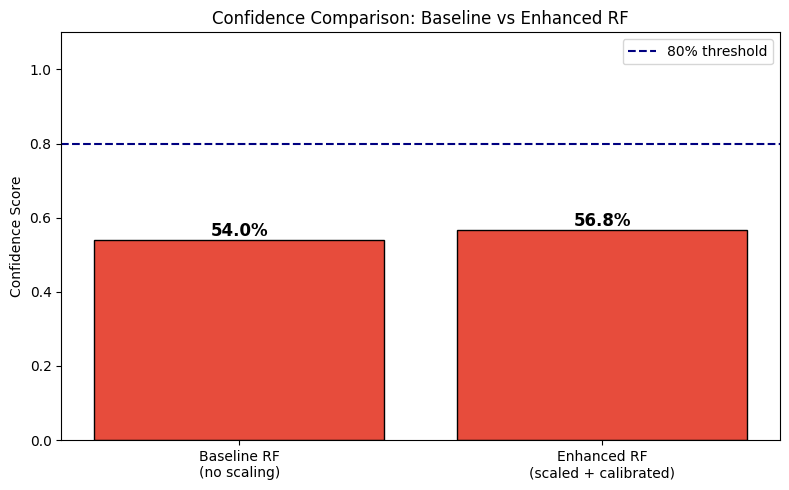


Baseline Confidence : 54.00%
Enhanced Confidence : 56.75%
Improvement         : +2.75%


In [15]:
sample_df = pd.DataFrame(
    [[90, 40, 40, 25, 80, 6.5, 200]],
    columns=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
)

enhanced_conf = max(final_pipeline.predict_proba(sample_df)[0])

models   = ['Baseline RF\n(no scaling)', 'Enhanced RF\n(scaled + calibrated)']
confs    = [baseline_conf, enhanced_conf]
colors   = ['#e74c3c' if c < 0.80 else '#2ecc71' for c in confs]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, confs, color=colors, edgecolor='black')
plt.axhline(0.80, color='navy', linestyle='--', linewidth=1.5, label='80% threshold')
for bar, conf in zip(bars, confs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{conf*100:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Confidence Score')
plt.title('Confidence Comparison: Baseline vs Enhanced RF')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBaseline Confidence : {baseline_conf*100:.2f}%")
print(f"Enhanced Confidence : {enhanced_conf*100:.2f}%")
print(f"Improvement         : +{(enhanced_conf - baseline_conf)*100:.2f}%")